# 12/22

let each balloon data time around longer time, find am data within +/- 36 hours

In [2]:
import pandas as pd 
import glob
import os
from datetime import datetime
import numpy as np

around_fn = './around_36h/' # 36 hours around balloon time
try:
    for file in glob.glob(f'{around_fn}/*.npz'):
        os.remove(file)
except OSError as e:
    print(f"Error removing files: {e}")

am_fn_list = glob.glob('./Data/time*.csv')
balloon_fn = './Data/Alldate_balloon_SP.csv'

am_fn_list.sort()
all_am_df = pd.DataFrame()

for am_fn in am_fn_list:
    am_df = pd.read_csv(am_fn, dtype={'DATE(YYYYMMDD)': str, 'START TIME(HHMMSS.Microsec)': str, 'PWV TOTAL zenith': str})
    am_df['TIME'] = pd.to_datetime(am_df['DATE(YYYYMMDD)'] + ' ' + am_df['START TIME(HHMMSS.Microsec)'], format='%Y%m%d %H%M%S.%f')
    am_df = am_df.sort_values(by='TIME') 
    am_TIME = am_df['TIME'].dt.strftime('%Y-%m-%d %H:%M:%S')
    am_PWV = am_df['PWV TOTAL zenith'].str.split(' ').str[0].astype(float)
    am_df_s = pd.DataFrame({'Time': am_TIME, 'PWV': am_PWV})
    all_am_df = pd.concat([all_am_df, am_df_s], ignore_index=True)

#print(f'Total AM data points: {len(all_am_df)} \n {all_am_df.head(3)} \n')
balloon_df = pd.read_csv(balloon_fn)
balloon_df['Date(YYYYMMDD_HHMMSS)'] = pd.to_datetime(balloon_df['Date(YYYYMMDD_HHMMSS)'], format='%Y%m%d_%H%M%S')
#print(f'Total Balloon data points: {len(balloon_df)} \n {balloon_df.head(3)} \n')

#am_num_out = 0

for i in range(len(balloon_df)):
    num_balloon = i
    balloon_time = balloon_df.loc[num_balloon, 'Date(YYYYMMDD_HHMMSS)']
    balloon_time_dt = datetime.strptime(str(balloon_time), '%Y-%m-%d %H:%M:%S')
    balloon_time_64 = np.datetime64(balloon_time_dt)
    balloon_date_fn = str(balloon_time_dt.strftime('%y%m%d_%H'))
    #print(f'Processing balloon time: {balloon_date_fn}')
    balloon_pwv = np.float64(balloon_df.loc[num_balloon, 'PWV(um)'])

    am_around_time_list = []
    am_around_pwv_list  = []

    for j in range(len(all_am_df)):
        num_am = j
        am_time = all_am_df.loc[num_am, 'Time']
        am_time_dt = datetime.strptime(am_time, '%Y-%m-%d %H:%M:%S')
        am_time_64 = np.datetime64(am_time_dt)
        am_pwv = all_am_df.loc[num_am, 'PWV']
        
        if ((balloon_time_dt - am_time_dt).total_seconds()) > 129600: # beyond +/- 36 hours
            continue
        elif abs((balloon_time_dt - am_time_dt).total_seconds()) < 129600: # within +/- 36 hours
            am_around_pwv_list.append(am_pwv)
            am_around_time_list.append(am_time_64)
        elif ((balloon_time_dt - am_time_dt).total_seconds()) < -129600:
            print(f'Finished balloon time: {balloon_date_fn} \n with am time: {am_time} \n')
            break
    
    if len(am_around_pwv_list) == 0:
        print(f'No AM data found around balloon time: {balloon_date_fn} \n')
        continue
    else:
        am_around_pwv_list = np.array(am_around_pwv_list, dtype=np.float64)
        am_around_time_list = np.array(am_around_time_list, dtype='datetime64[ns]')
        np.savez_compressed(
            f'{around_fn}/around_{balloon_date_fn}.npz',
            balloon_time=balloon_time_64,
            balloon_pwv=balloon_pwv,
            am_around_time=am_around_time_list,
            am_around_pwv=am_around_pwv_list
        )            

    if i == 1:
        break #test
    if i % 10 == 0:
        print(f'Done for balloon time: {balloon_date_fn} \n')



Finished balloon time: 240101_00 
 with am time: 2024-01-03 01:01:35 

No AM data found around balloon time: 240101_00 

Finished balloon time: 240101_12 
 with am time: 2024-01-03 01:01:35 

No AM data found around balloon time: 240101_12 

Finished balloon time: 240102_12 
 with am time: 2024-01-04 01:01:35 

Finished balloon time: 240103_00 
 with am time: 2024-01-04 13:01:36 

Finished balloon time: 240103_12 
 with am time: 2024-01-05 01:01:35 

Finished balloon time: 240104_00 
 with am time: 2024-01-05 13:01:35 

Finished balloon time: 240104_12 
 with am time: 2024-01-06 01:01:36 

Finished balloon time: 240105_00 
 with am time: 2024-01-06 13:01:36 

Finished balloon time: 240105_12 
 with am time: 2024-01-07 01:01:35 

Finished balloon time: 240106_00 
 with am time: 2024-01-07 13:01:36 

Finished balloon time: 240106_12 
 with am time: 2024-01-08 01:01:36 

Done for balloon time: 240106_12 

Finished balloon time: 240107_00 
 with am time: 2024-01-08 13:01:35 

Finished ball

In [ ]:
import pandas as pd 
import numpy as np  
import matplotlib.pyplot as plt
import glob
import os
from datetime import datetime
import pickle
import matplotlib.pyplot as plt 
import pickle

"""
Plot the Histogram for PWV diff(%) for each csv files
"""
#fns
hist_dir = 'Hist_36h_CB3' ###
stats_fn = 'Total_around36h_stats_CB3.txt'

try:
    os.remove(f'{stats_fn}')
except OSError as e:
    print(f"{e}")
around_36h_path = './around_36h/'
around_fn_list = glob.glob(f'{around_36h_path}/*.npz')

total_data_pwv_diff = []
total_data_DeltaT = []

for around_fn in around_fn_list:
    around_df_npz = np.load(around_fn)
    balloon_PWV = around_df_npz['balloon_pwv']
    am_PWV = around_df_npz['am_around_pwv']
    am_TIME = around_df_npz['am_around_time']
    balloon_TIME = around_df_npz['balloon_time']

    pwv_diff_perc = (am_PWV - balloon_PWV) / balloon_PWV * 100
    total_data_pwv_diff.extend(pwv_diff_perc)

    
    for am_t in am_TIME:
        am_time_dt = np.datetime64(am_t)
        bal_time_dt = np.datetime64(balloon_TIME)
        delta_t = int((am_time_dt - bal_time_dt) / np.timedelta64(1, 'm'))
        if delta_t not in total_data_DeltaT:
            if (delta_t + 1) in total_data_DeltaT:
                delta_t += 1
            elif (delta_t - 1) in total_data_DeltaT:
                delta_t -= 1
        total_data_DeltaT.append(delta_t)

total_data = pd.DataFrame({
    'PWV_diff': total_data_pwv_diff,
    'Delta_T': total_data_DeltaT
})

total_data.to_csv('Total_around36h_data_CB3.csv', index=False)
print(f'Total data points collected: {len(total_data)} \n')



[WinError 2] 系统找不到指定的文件。: 'Total_around36h_stats_CB3.txt'
Total data points collected: 292356 

Unique Delta_T values: [-2098 -2093 -2088 -2083 -2078 -2073 -2068 -2063 -2058 -2053 -2048 -2038
 -2033 -2028 -2023 -2018 -2013 -2008 -2003 -1997 -1992 -1987 -1978 -1973
 -1968 -1963 -1958 -1953 -1948 -1943 -1938 -1933 -1928 -1858 -1853 -1848
 -1843 -1838 -1833 -1828 -1823 -1818 -1813 -1807 -1798 -1793 -1788 -1783
 -1778 -1773 -1768 -1763 -1758 -1753 -1748 -1738 -1733 -1728 -1723 -1718
 -1713 -1708 -1703 -1698 -1693 -1688 -1618 -1613 -1608 -1603 -1598 -1593
 -1588 -1583 -1578 -1573 -1568 -1558 -1553 -1548 -1543 -1538 -1533 -1528
 -1523 -1518 -1513 -1508 -1498 -1493 -1488 -1483 -1478 -1473 -1468 -1463
 -1458 -1453 -1448 -1378 -1373 -1368 -1363 -1358 -1353 -1348 -1343 -1338
 -1333 -1328 -1318 -1313 -1308 -1303 -1298 -1293 -1288 -1283 -1277 -1272
 -1267 -1258 -1253 -1248 -1243 -1238 -1233 -1228 -1223 -1218 -1213 -1208
 -1138 -1133 -1128 -1123 -1118 -1113 -1108 -1103 -1098 -1093 -1087 -1078
 -107

In [23]:
try:
    os.remove(f'{stats_fn}')
except OSError as e:
    print(f"{e}")

total_data = pd.read_csv('Total_around36h_data_CB3.csv')
total_data.sort_values(by='Delta_T', inplace=True)

#find all possible delta_T in total_data
unique_delta_T = total_data['Delta_T'].unique()
#print(f'Unique Delta_T values: {unique_delta_T}')

MIN_COUNT = 2        # keep bins with >=2 points
ROUND_DECIMALS = 0     #  bins

for unique_t in unique_delta_T:
    subset = total_data[total_data['Delta_T'] == unique_t].copy()

    # round to create "repeatable" bins
    subset['PWV_bin'] = subset['PWV_diff'].round(ROUND_DECIMALS)

    # keep bins that appear often enough
    vc = subset['PWV_bin'].value_counts()
    subset_cb3 = subset[subset['PWV_bin'].map(vc) >= MIN_COUNT]

    if subset_cb3.empty:
        print(f"Delta_T={unique_t}: nothing after filter (n={len(subset)})")
        continue

    mean_pwv_diff = subset_cb3['PWV_diff'].mean()
    mean = np.mean(subset_cb3['PWV_diff'])
    std_pwv_diff = subset_cb3['PWV_diff'].std()
    count = len(subset_cb3)

    with open(f'{stats_fn}', 'a+') as f:
        f.write(f"Delta_T: {unique_t} min, Count: {count}, Mean PWV Diff (%): {mean_pwv_diff:.2f}, Std Dev: {std_pwv_diff:.2f}\n")
    
    #make plot for each subset

    plt.figure(figsize=(8,6))
    plt.hist(subset_cb3['PWV_diff'], bins=50, alpha=0.7, color='blue', edgecolor='black',
             label=f'Mean: {mean_pwv_diff:.2f}%, Std Dev: {std_pwv_diff:.2f}, Count: {count}')
    plt.title(f'Histogram of PWV Difference (%) for Delta_T = {unique_t} min')
    plt.xlabel('PWV Difference (%)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.legend()
    if count > 200:
        plt.savefig(f'{hist_dir}/DeltaT_{unique_t}_pwv_diff.png')
    else:
        plt.savefig(f'{hist_dir}/LessDPS/DeltaT_{unique_t}_pwv_diff.png') #not excepted happens
    plt.close()
    #break
    

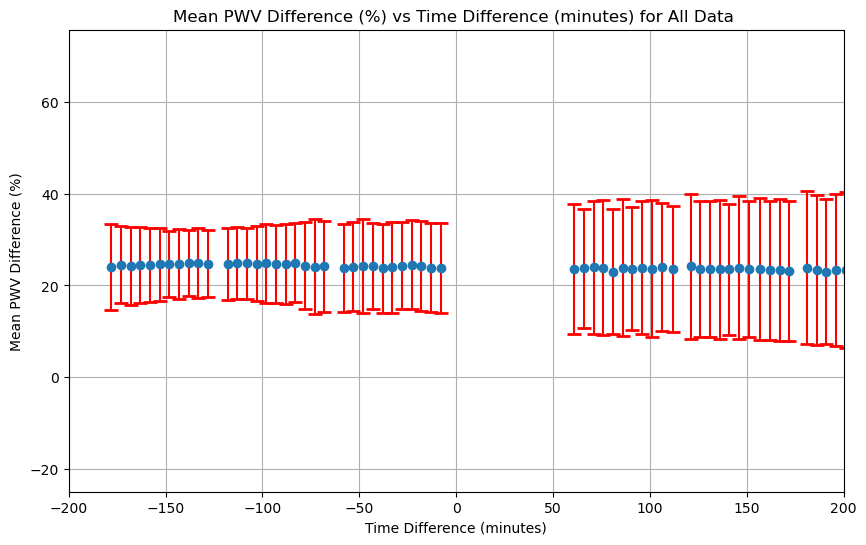

In [25]:
# read txt file

Delta_Ts = []   
mean_PWV_diffs = []
counts = []
Std_devs = []

with open(f'{stats_fn}', 'r') as f:
    lines = f.readlines()
    for line in lines:
        parts = line.strip().split(',')
        delta_T = float(parts[0].split(':')[1].strip().split(' ')[0])
        count = int(parts[1].split(':')[1].strip())
        # if count < 200:
        #     continue
        mean_PWV_diff = float(parts[2].split(':')[1].strip())
        std_dev = float(parts[3].split(':')[1].strip())
        
        Delta_Ts.append(delta_T)
        counts.append(count)
        mean_PWV_diffs.append(mean_PWV_diff)
        Std_devs.append(std_dev)
#print(Delta_Ts)
new_total = pd.DataFrame({
    'Delta_T': Delta_Ts,
    'Mean_PWV_Diff': mean_PWV_diffs,
})
new_total = new_total.sort_values(by='Delta_T')
new_total.to_csv('Total_around36h_CB3_filtered.csv', index=False)
plt.figure(figsize=(10,6))
plt.errorbar(Delta_Ts, mean_PWV_diffs, yerr=Std_devs, fmt='o', ecolor='r', capthick=2, capsize=5)
plt.xlabel('Time Difference (minutes)')
plt.ylabel('Mean PWV Difference (%)')
plt.title('Mean PWV Difference (%) vs Time Difference (minutes) for All Data ')
plt.grid()
plt.xlim(-200, 200)
plt.savefig('All_Data_Errorbar_36h_CB3_-200_200.png')
plt.show()
plt.close()

# plt.figure(figsize=(10,6))
# plt.scatter(Delta_Ts, mean_PWV_diffs)
# plt.xlabel('Time Difference (minutes)')
# plt.ylabel('Mean PWV Difference (%)')
# plt.title('Mean PWV Difference (%) vs Time Difference (minutes) for All Data  ')
# plt.grid()
# plt.savefig('All_Data_Scatter_36h_CB3.png')
# plt.show()
# plt.close()

# 12/18
first try to compare to around WVR data to Balloon data 

In [ ]:
"""
read from floder ./Data/*.csv to have all am data (time and pwv)
read balloon data from ./Data/Alldate_balloon_SP.csv
regenerate a new csv by following conditions:
for each balloon data time, find am data within +/- 120 min
save new csv to ./around_balloon_am_data.csv
"""

import pandas as pd 
import numpy as np  
#import matplotlib.pyplot as plt
import glob
import os
from datetime import datetime, timedelta
import pickle
import matplotlib.pyplot as plt   

try:
    for file in glob.glob('./around/*.csv'):
        os.remove(file)
except OSError as e:
    print(f"Error removing files: {e}")

am_fn_list = glob.glob('./Data/time*.csv')
balloon_fn = './Data/Alldate_balloon_SP.csv'

am_fn_list.sort()
all_am_df = pd.DataFrame()

for am_fn in am_fn_list:
    am_df = pd.read_csv(am_fn, dtype={'DATE(YYYYMMDD)': str, 'START TIME(HHMMSS.Microsec)': str, 'PWV TOTAL zenith': str})
    am_df['TIME'] = pd.to_datetime(am_df['DATE(YYYYMMDD)'] + ' ' + am_df['START TIME(HHMMSS.Microsec)'], format='%Y%m%d %H%M%S.%f')
    am_df = am_df.sort_values(by='TIME') 
    am_TIME = am_df['TIME'].dt.strftime('%Y-%m-%d %H:%M:%S')
    am_PWV = am_df['PWV TOTAL zenith'].str.split(' ').str[0].astype(float)
    am_df_s = pd.DataFrame({'Time': am_TIME, 'PWV': am_PWV})
    all_am_df = pd.concat([all_am_df, am_df_s], ignore_index=True)

#print(f'Total AM data points: {len(all_am_df)} \n {all_am_df.head(3)} \n')
balloon_df = pd.read_csv(balloon_fn)
balloon_df['Date(YYYYMMDD_HHMMSS)'] = pd.to_datetime(balloon_df['Date(YYYYMMDD_HHMMSS)'], format='%Y%m%d_%H%M%S')
#print(f'Total Balloon data points: {len(balloon_df)} \n {balloon_df.head(3)} \n')

#save csv function for each balloon time
def saveAround(balloon_date_fn, am_time, am_pwv, balloon_time, balloon_pwv):
    if os.path.exists(f'around/around_{balloon_date_fn}.csv') is False:
        with open(f'around/around_{balloon_date_fn}.csv', 'w+') as f:
            f.write('am_TIME, am_PWV(um), balloon_TIME, balloon_PWV(um) \n')
            f.write(f'{am_time}, {am_pwv}, {balloon_time}, {balloon_pwv} \n')
    else:
        with open(f'around/around_{balloon_date_fn}.csv', 'a+') as f:
            f.write(f'{am_time}, {am_pwv}, {balloon_time}, {balloon_pwv} \n')

am_num_out = 0

for i in range(3, len(balloon_df)):
    num_balloon = i
    balloon_time = balloon_df.loc[num_balloon, 'Date(YYYYMMDD_HHMMSS)']
    balloon_time_dt = datetime.strptime(str(balloon_time), '%Y-%m-%d %H:%M:%S')
    balloon_date_fn = str(balloon_time_dt.strftime('%y%m%d_%H'))
    #print(f'Processing balloon time: {balloon_date_fn}')
    balloon_pwv = balloon_df.loc[num_balloon, 'PWV(um)']

    for j in range(am_num_out, len(all_am_df)):
        num_am = j
        am_time = all_am_df.loc[num_am, 'Time']
        am_time_dt = datetime.strptime(am_time, '%Y-%m-%d %H:%M:%S')
        am_pwv = all_am_df.loc[num_am, 'PWV']
        #print(f'  Checking AM data index: {num_am} to {am_time_dt}' )
        if balloon_time_dt.hour == 0:
            if am_time_dt.month == balloon_time_dt.month and am_time_dt.year == balloon_time_dt.year: 
                if abs((am_time_dt - balloon_time_dt).total_seconds()) <= 7200:
                    saveAround(balloon_date_fn, am_time, am_pwv, balloon_time, balloon_pwv)
                    am_num_out += 1
                    continue
                elif am_time_dt.day < balloon_time_dt.day:
                    am_num_out += 1
                    continue
                elif am_time_dt.day > balloon_time_dt.day:
                    am_num_out += 1
                    break

        if balloon_time_dt.hour == 12:
            same_day = am_time_dt.day == balloon_time_dt.day
            same_month = am_time_dt.month == balloon_time_dt.month
            same_year = am_time_dt.year == balloon_time_dt.year
            if same_day and same_month and same_year:
                if balloon_time_dt.hour - am_time_dt.hour > 2:
                    am_num_out += 1
                    continue
                elif abs((am_time_dt - balloon_time_dt).total_seconds()) <= 7200:
                    saveAround(balloon_date_fn, am_time, am_pwv, balloon_time, balloon_pwv)
                    am_num_out += 1
                    continue
                elif am_time_dt.hour - balloon_time_dt.hour > 2:
                    am_num_out += 1
                    break
                else:
                    print(f"not excepted case for {am_time_dt}")
                    am_num_out += 1
                    continue

    if i == 1:
        break #test
    if i % 20 == 0:
        print(f'Done for balloon time: {balloon_date_fn} \n')



In [ ]:
import pandas as pd 
import numpy as np  
import matplotlib.pyplot as plt
import glob
import os
from datetime import datetime, timedelta
import pickle
import matplotlib.pyplot as plt 

"""
Plot the Histogram for PWV diff(%) for each csv files
"""

try:
    os.remove('Total_around_stats.txt')
except OSError as e:
    print(f"Error creating directory: {e}")

around_fn_list = glob.glob('./around/*.csv')

total_data_pwv_diff = []
total_data_DeltaT = []

for around_fn in around_fn_list:
    around_df = pd.read_csv(around_fn)
    # Strip whitespace from column names
    around_df.columns = around_df.columns.str.strip() ###

    am_PWV = around_df['am_PWV(um)'].values
    balloon_PWV = around_df['balloon_PWV(um)'].values
    pwv_diff_perc = (am_PWV - balloon_PWV) / balloon_PWV * 100
    total_data_pwv_diff.extend(pwv_diff_perc)

    am_TIME = around_df['am_TIME'].values
    balloon_TIME = around_df['balloon_TIME'].values
    
    for am_t, bal_t in zip(am_TIME, balloon_TIME):
        am_time_dt = datetime.strptime(am_t, '%Y-%m-%d %H:%M:%S')
        bal_time_dt = datetime.strptime(bal_t, ' %Y-%m-%d %H:%M:%S')
        delta_t = int((am_time_dt - bal_time_dt).total_seconds() / 60)  # in minutes
        if delta_t not in total_data_DeltaT:
            if (delta_t + 1) in total_data_DeltaT:
                delta_t += 1
            elif (delta_t - 1) in total_data_DeltaT:
                delta_t -= 1
        total_data_DeltaT.append(delta_t)

total_data = pd.DataFrame({
    'PWV_diff': total_data_pwv_diff,
    'Delta_T': total_data_DeltaT
})

total_data.sort_values(by='Delta_T', inplace=True)

#find all possible delta_T in total_data
unique_delta_T = total_data['Delta_T'].unique()
print(f'Unique Delta_T values: {unique_delta_T}')
for unique_t in unique_delta_T:
    subset = total_data[total_data['Delta_T'] == unique_t]
    mean_pwv_diff = subset['PWV_diff'].mean()
    mean = np.mean(subset['PWV_diff'])
    if mean != mean_pwv_diff:
        print(f"Mean mismatch for Delta_T {unique_t}: mean()={mean}, mean_pwv_diff={mean_pwv_diff}")
        break
    std_pwv_diff = subset['PWV_diff'].std()
    count = len(subset)

    with open('Total_around_stats.txt', 'a+') as f:
        f.write(f"Delta_T: {unique_t} min, Count: {count}, Mean PWV Diff (%): {mean_pwv_diff:.2f}, Std Dev: {std_pwv_diff:.2f}\n")
    
    #make plot for each subset

    plt.figure(figsize=(8,6))
    plt.hist(subset['PWV_diff'], bins=30, alpha=0.7, color='blue', edgecolor='black',
             label=f'Mean: {mean_pwv_diff:.2f}%, Std Dev: {std_pwv_diff:.2f}, Count: {count}')
    plt.title(f'Histogram of PWV Difference (%) for Delta_T = {unique_t} min')
    plt.xlabel('PWV Difference (%)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.legend()
    if count > 200:
        plt.savefig(f'Hist/DeltaT_{unique_t}_pwv_diff.png')
    else:
        plt.savefig(f'Hist/LessDPS/DeltaT_{unique_t}_pwv_diff.png') #not excepted happens
    plt.close()
    

In [ ]:
import pandas as pd 
import numpy as np  
import matplotlib.pyplot as plt
import glob
import os
from datetime import datetime, timedelta
import pickle
import matplotlib.pyplot as plt

# read txt file

Delta_Ts = []   
mean_PWV_diffs = []
counts = []
Std_devs = []

with open('total_around_stats.txt', 'r') as f:
    lines = f.readlines()
    for line in lines:
        parts = line.strip().split(',')
        delta_T = float(parts[0].split(':')[1].strip().split(' ')[0])
        count = int(parts[1].split(':')[1].strip())
        # if count < 200:
        #     continue
        mean_PWV_diff = float(parts[2].split(':')[1].strip())
        std_dev = float(parts[3].split(':')[1].strip())
        
        Delta_Ts.append(delta_T)
        counts.append(count)
        mean_PWV_diffs.append(mean_PWV_diff)
        Std_devs.append(std_dev)
#print(Delta_Ts)
new_total = pd.DataFrame({
    'Delta_T': Delta_Ts,
    'Mean_PWV_Diff': mean_PWV_diffs,
})
new_total = new_total.sort_values(by='Delta_T')
new_total.to_csv('Total_around_filtered.csv', index=False)

plt.figure(figsize=(10,6))
plt.errorbar(Delta_Ts, mean_PWV_diffs, yerr=Std_devs, fmt='o', ecolor='r', capthick=2, capsize=5)
plt.xlabel('Time Difference (minutes)')
plt.ylabel('Mean PWV Difference (%)')
plt.title('Mean PWV Difference (%) vs Time Difference (minutes) for All Data ')
plt.grid()
plt.savefig('All_Data_Errorbar.png')
plt.show()
plt.close()
plt.figure(figsize=(10,6))
plt.scatter(Delta_Ts, mean_PWV_diffs)
plt.xlabel('Time Difference (minutes)')
plt.ylabel('Mean PWV Difference (%)')
plt.title('Mean PWV Difference (%) vs Time Difference (minutes) for All Data  ')
plt.grid()
plt.savefig('All_Data_Scatter.png')
plt.show()
plt.close()
